# Exploratory Analysis

Seasonal patterns, long term trends, and variable relationships across 45 years of ERA5 reanalysis data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
bcolor = "darkslategrey"

month_lbls = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df = pd.read_csv("../data/processed/mendoza_basin_monthly.csv", parse_dates=["time"], index_col="time")

print(f"Loaded {len(df)} months ({df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')})")
print(f"Variables: {list(df.columns)}")
df.head()

Loaded 540 months (1980-01 to 2024-12)
Variables: ['precip_mm', 'temp_c', 'pev_mm', 'runoff_mm', 'soil_moisture_0_7cm']


,precip_mm,temp_c,pev_mm,runoff_mm,soil_moisture_0_7cm
time,,,,,
1980-01-01,63.820649,15.302368,183.912286,98.165597,0.191278
1980-02-01,93.886005,13.928650,148.222182,36.150087,0.191747
1980-03-01,66.787061,14.917786,132.601721,29.331790,0.162673
1980-04-01,162.947316,6.125000,59.435077,35.352784,0.201941
1980-05-01,115.186830,3.713196,39.293950,28.664771,0.218384


## Seasonal Climatology

I average the monthly values across all 45 years. This is to show the basin's normal water cycle. When it rains, when evaporation is at its peak, and when water stress occurs.


Mean annual precipitation:   806mm
Mean annual PET:             1247mm
Annual water deficit:       -441mm

Monthly Climate Extremes
Wettest Month: Jun
Driest Month:  Apr
Coldest Month: Jan
Warmest Month: Jul


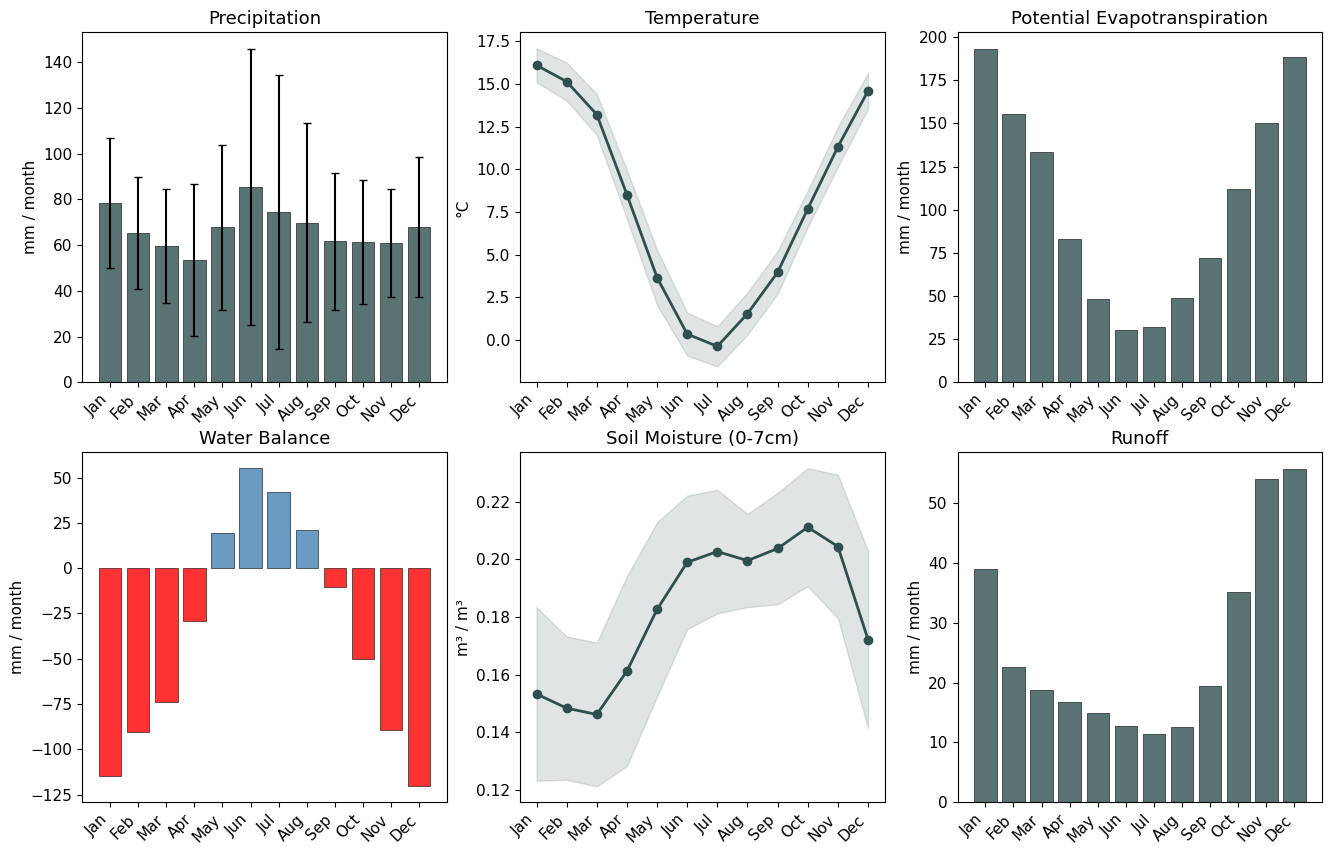

In [13]:
monthly_clim = df.groupby(df.index.month).agg(["mean", "std"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
months = range(1, 13)

# Precipitation
ax = axes[0, 0]
means = monthly_clim["precip_mm"]["mean"]
stds = monthly_clim["precip_mm"]["std"]
ax.bar(months, means, yerr=stds, color=bcolor, alpha=0.8, capsize=3, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Precipitation")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Temperature
ax = axes[0, 1]
means = monthly_clim["temp_c"]["mean"]
stds = monthly_clim["temp_c"]["std"]
ax.plot(months, means, "o-", color=bcolor, linewidth=2)
ax.fill_between(months, means - stds, means + stds, color=bcolor, alpha=0.15)
ax.set_ylabel("°C")
ax.set_title("Temperature")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# PET
ax = axes[0, 2]
means = monthly_clim["pev_mm"]["mean"]
ax.bar(months, means, color=bcolor, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Potential Evapotranspiration")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Water Balance
ax = axes[1, 0]
p_means = monthly_clim["precip_mm"]["mean"]
pet_means = monthly_clim["pev_mm"]["mean"]
deficit = p_means.values - pet_means.values 
colors = ["steelblue" if d >= 0 else "red" for d in deficit]
ax.bar(months, deficit, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Water Balance")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Soil Moisture
ax = axes[1, 1]
means = monthly_clim["soil_moisture_0_7cm"]["mean"]
stds = monthly_clim["soil_moisture_0_7cm"]["std"]
ax.plot(months, means, "o-", color=bcolor, linewidth=2)
ax.fill_between(months, means - stds, means + stds, color=bcolor, alpha=0.15)
ax.set_ylabel("m³ / m³")
ax.set_title("Soil Moisture (0-7cm)")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Runoff
ax = axes[1, 2]
means = monthly_clim["runoff_mm"]["mean"]
ax.bar(months, means, color=bcolor, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Runoff")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Overall Statistics
annual_precip = monthly_clim["precip_mm"]["mean"].sum()
annual_pet = monthly_clim["pev_mm"]["mean"].sum()
print(f"\nMean annual precipitation:   {annual_precip:.0f}mm")
print(f"Mean annual PET:             {annual_pet:.0f}mm")
print(f"Annual water deficit:       {annual_precip - annual_pet:.0f}mm")
print(f"\nMonthly Climate Extremes")
print(f"Wettest Month: {month_lbls[monthly_clim["precip_mm"]["mean"].idxmax()-1]}")
print(f"Driest Month:  {month_lbls[monthly_clim["precip_mm"]["mean"].idxmin()-1]}")
print(f"Coldest Month: {month_lbls[monthly_clim["temp_c"]["mean"].idxmax()-1]}")
print(f"Warmest Month: {month_lbls[monthly_clim["temp_c"]["mean"].idxmin()-1]}")